# 05 · Model Evaluation by ABC-XYZ Segment

Aggregate RMSE/MAPE is a weak signal — it hides *where* the forecast is good
or bad. Breaking validation error down by **ABC-XYZ cell** is the finding that
makes the analysis senior: it shows *why* the model performs differently on
different inventory types.

The numbers below come from `python -m src.evaluation`
(`outputs/segment_performance.csv`), which scores three forecasters per cell on
the held-out 28 days:

- **direct** — the deployed horizon-safe LightGBM model (`lgbm_v1.pkl`),
- **recursive** — the recursive multi-step model,
- **baseline** — the naive lag-7 seasonal forecast.

Segments are defined on the **training window** (revenue = units x price).

In [1]:
import sys

sys.path.append("..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plotting import configure_matplotlib

configure_matplotlib()

## Segment performance table

One row per ABC-XYZ cell: SKU count, per-model RMSE/MAPE, the MTS/MTO policy,
and each model's RMSE improvement over the naive baseline.

In [3]:
table = pd.read_csv("../outputs/segment_performance.csv")
table

,abc_xyz,n_skus,n_obs,direct_rmse,direct_mape,recursive_rmse,recursive_mape,baseline_rmse,baseline_mape,abc_class,xyz_class,policy,direct_vs_baseline_pct,recursive_vs_baseline_pct
0,AX,1008,28224,3.5131,51.9295,3.4354,52.6898,4.4878,75.6520,A,X,MTS,21.7,23.5
1,AY,5173,144844,3.3933,55.7912,3.2107,55.7194,4.0106,81.5742,A,Y,MTS,15.4,19.9
2,AZ,1868,52304,3.6070,56.7287,3.2993,55.1919,4.1861,79.8896,A,Z,MTS,13.8,21.2
3,BX,148,4144,1.7373,49.3308,1.7519,50.6855,2.3840,84.1516,B,X,MTS,27.1,26.5
4,BY,4607,128996,1.8427,54.9013,1.8580,55.6604,2.5521,86.1636,B,Y,MTS,27.8,27.2
5,BZ,3946,110488,1.8308,55.5969,1.7773,53.8404,2.2653,82.7335,B,Z,MTS/review,19.2,21.5
6,CX,14,392,1.9082,46.0652,1.9084,54.4162,2.2874,84.0997,C,X,MTS,16.6,16.6
7,CY,1718,48104,1.4709,58.0806,1.4832,57.7758,2.0278,87.0715,C,Y,MTS/review,27.5,26.9
8,CZ,12008,336224,1.1075,62.2689,1.0954,59.7041,1.4139,84.4996,C,Z,MTO,21.7,22.5


## Key finding: RMSE measures volume, MAPE measures predictability

Two different stories, and the distinction is the point:

- **Absolute RMSE is dominated by demand *volume*, not predictability.** The
  high-value **A** cells have the *highest* RMSE (~3.4) simply because those SKUs
  sell the most units, so absolute errors are larger; the low-value **CZ** cell
  has the *lowest* RMSE (~1.1) because its demand is near zero. Ranking segments
  by raw RMSE is therefore misleading.
- **MAPE (relative error) reveals the predictability gradient.** It rises with
  demand variability X → Y → Z within every value tier, and **CZ is the single
  hardest cell (~62%)** — erratic, intermittent demand is genuinely the toughest
  to forecast, exactly as the ABC-XYZ framing predicts. The *variability* (XYZ)
  axis moves MAPE far more than the *value* (ABC) axis.

Both models beat the naive baseline in **every** cell (+14% to +28% RMSE), so the
model earns its keep across all inventory types — which is why Sprint 5 can set
*different service levels* per cell (99% for AX down to MTO for CZ).

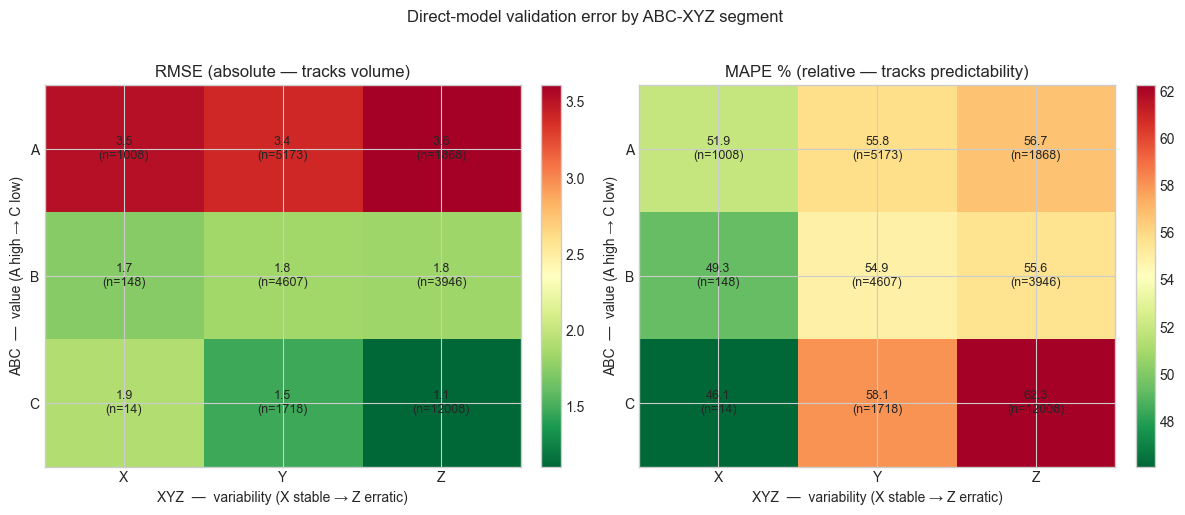

In [4]:
rows, cols = ["A", "B", "C"], ["X", "Y", "Z"]


def grid(col):
    return table.pivot(index="abc_class", columns="xyz_class", values=col).reindex(index=rows, columns=cols)


n_grid = grid("n_skus")
panels = [
    ("direct_rmse", "RMSE (absolute — tracks volume)"),
    ("direct_mape", "MAPE % (relative — tracks predictability)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (col, title) in zip(axes, panels):
    g = grid(col)
    im = ax.imshow(g.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(3), cols)
    ax.set_yticks(range(3), rows)
    ax.set_xlabel("XYZ  —  variability (X stable → Z erratic)")
    ax.set_ylabel("ABC  —  value (A high → C low)")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            v, n = g.values[i, j], n_grid.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.1f}\n(n={int(n)})", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Direct-model validation error by ABC-XYZ segment", y=1.02)
fig.tight_layout()
fig.savefig("../outputs/segment_error_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Model vs. baseline lift by segment

Where does the model earn its keep? A positive lift means lower RMSE than the
naive lag-7 baseline. The lift is **positive in every cell** (+14% to +28%),
confirming the model beats a trivial forecaster across all inventory types.
Interestingly it's *smallest* on the high-value **A** cells (~14–15%), where
demand is large and the seasonal baseline is already a decent guess, and largest
on the moderate B/C cells. The recursive model adds a further edge on the
high-volume A cells, where the short lags it feeds back carry the most signal.

In [5]:
lift_cols = ["abc_xyz", "n_skus", "direct_rmse", "baseline_rmse", "direct_vs_baseline_pct"]
if "recursive_vs_baseline_pct" in table.columns:
    lift_cols[3:3] = ["recursive_rmse"]
    lift_cols.append("recursive_vs_baseline_pct")
table[lift_cols].sort_values("direct_vs_baseline_pct", ascending=False)

,abc_xyz,n_skus,direct_rmse,recursive_rmse,baseline_rmse,direct_vs_baseline_pct,recursive_vs_baseline_pct
4,BY,4607,1.8427,1.8580,2.5521,27.8,27.2
7,CY,1718,1.4709,1.4832,2.0278,27.5,26.9
3,BX,148,1.7373,1.7519,2.3840,27.1,26.5
0,AX,1008,3.5131,3.4354,4.4878,21.7,23.5
8,CZ,12008,1.1075,1.0954,1.4139,21.7,22.5
5,BZ,3946,1.8308,1.7773,2.2653,19.2,21.5
6,CX,14,1.9082,1.9084,2.2874,16.6,16.6
1,AY,5173,3.3933,3.2107,4.0106,15.4,19.9
2,AZ,1868,3.6070,3.2993,4.1861,13.8,21.2


## Residual distributions per ABC-XYZ cell (SCDF-21)

Aggregate RMSE/MAPE says *how big* the errors are on average; the residual
*distribution* says how they're shaped — which is what Sprint 5's safety
stock calculation needs directly. Per `docs/inventory-policy.md`, each
segment's service-level Z-score is applied to its forecast-error sigma
(`SS = Z x sigma x sqrt(lead_time)`), so this section is the literal
statistical input to that formula, produced by
`compute_error_stats(y_true, y_pred, segments)` in `src/evaluation.py` and
persisted to `outputs/error_stats.csv` by `python -m src.evaluation`.

In [6]:
residuals = pd.read_parquet("../data/processed/direct_val_residuals.parquet")
error_stats = pd.read_csv("../outputs/error_stats.csv")
error_stats

,abc_xyz,n_obs,bias,sigma,skew,shapiro_p,is_normal
0,AX,28224,0.2047,3.5071,1.9553,0.0,False
1,AY,144844,0.2416,3.3847,5.2255,0.0,False
2,AZ,52304,0.4407,3.5800,3.0387,0.0,False
3,BX,4144,-0.0336,1.7371,1.5667,0.0,False
4,BY,128996,0.0421,1.8422,4.3660,0.0,False
5,BZ,110488,0.1585,1.8240,6.8362,0.0,False
6,CX,392,-0.0547,1.9098,3.4214,0.0,False
7,CY,48104,0.0200,1.4707,5.4898,0.0,False
8,CZ,336224,0.0613,1.1058,7.7726,0.0,False


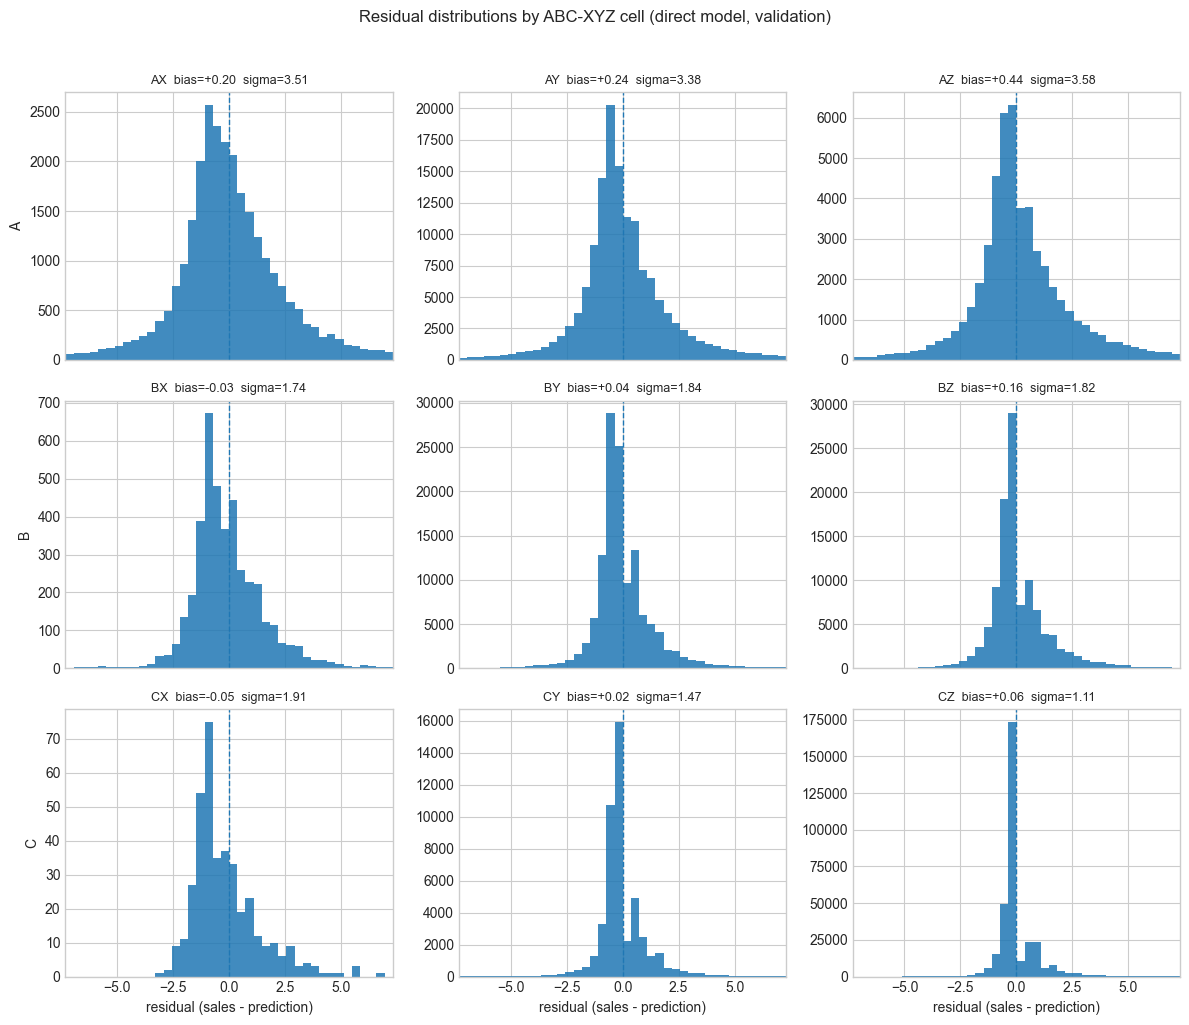

In [7]:
rows, cols = ["A", "B", "C"], ["X", "Y", "Z"]
stats_idx = error_stats.set_index("abc_xyz")

# Shared x-limits (1st/99th percentile) so subplot width honestly encodes sigma.
lo, hi = residuals["residual"].quantile([0.01, 0.99])
xlim = (min(lo, -hi), max(hi, -lo))

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=False)
for i, abc in enumerate(rows):
    for j, xyz in enumerate(cols):
        cell = f"{abc}{xyz}"
        ax = axes[i, j]
        vals = residuals.loc[residuals["abc_xyz"] == cell, "residual"]
        if len(vals) == 0:
            ax.set_visible(False)
            continue
        ax.hist(vals, bins=40, range=xlim, alpha=0.85)
        ax.axvline(0, linestyle="--", linewidth=1)
        if cell in stats_idx.index:
            s = stats_idx.loc[cell]
            ax.set_title(f"{cell}  bias={s['bias']:+.2f}  sigma={s['sigma']:.2f}", fontsize=9)
        ax.set_xlim(*xlim)
        if i == 2:
            ax.set_xlabel("residual (sales - prediction)")
        if j == 0:
            ax.set_ylabel(abc)

fig.suptitle("Residual distributions by ABC-XYZ cell (direct model, validation)", y=1.02)
fig.tight_layout()
fig.savefig("../outputs/error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Key finding: bias is small and mostly one-directional, but sigma and skew tell different stories

- **Bias is small everywhere** (|bias| from 0.02 to 0.44 units) and **positive
  in 7 of 9 cells** — the direct model has a mild, consistent tendency to
  *under-forecast*. The two negative-bias cells (BX, CX) are also the two
  smallest by observation count (4,144 and 392 rows), so that sign flip is
  plausibly noise rather than a real over-forecasting pattern. The largest
  single bias is **AZ (+0.44)** — the model under-forecasts high-value,
  erratic items the most, which is the costliest place to under-forecast
  (lost sales on a top-revenue SKU). This is a finding to carry into Sprint 5
  sizing, not a defect to patch here.
- **Sigma (absolute) tracks demand volume, not variability — mirroring the
  RMSE finding above.** A-tier cells have the *largest* absolute sigma
  (~3.4–3.6) and C-tier the *smallest* (~1.1–1.9), even though the C items
  are the more erratic ones by CV. So the AC's hypothesis ("AX tighter than
  CZ") does **not** hold for raw sigma — the opposite is true, for the same
  reason RMSE ranks A-cells highest: absolute error magnitude scales with
  how much a SKU sells, not how erratic it is.
- **Skew is where the variability gradient actually shows up.** Every cell is
  strongly right-skewed, and skew rises consistently from X to Z within the B
  and C tiers (BX 1.57 -> BY 4.37 -> BZ 6.84; CX 3.42 -> CY 5.49 -> CZ 7.77):
  as demand gets more erratic, the error distribution's *shape* gets more
  lopsided even though its absolute *width* shrinks. `CZ` has the narrowest
  sigma of any cell but the most extreme skew (7.77) — a few large
  under-forecasts pull a mostly-tight distribution's tail out.
- **`is_normal` is `False` for all nine cells** (Shapiro-Wilk, p ~ 0), but at
  n = 392 to 336k observations per cell, Shapiro-Wilk rejects normality for
  almost any real distribution at that sample size — the binary flag isn't
  informative here. The skew column is the more useful signal: the erratic
  (Z-class) segments have the most asymmetric errors, which is exactly where
  Sprint 5's `SS = Z x sigma x sqrt(lead_time)` normal-approximation is
  weakest — worth flagging as a known limitation when the safety-stock policy
  ships, particularly for CZ/BZ/AZ.

## Feature importance via SHAP (SCDF-22)

RMSE/MAPE and the residual stats above say *how well* the model forecasts;
they say nothing about *what it's using* to get there. SHAP (SHapley Additive
exPlanations) attributes each prediction to its input features in a way
that's additive and comparable across rows, so we can rank global feature
importance and also ask whether a feature's importance is uniform across
product categories -- useful when a stakeholder asks "does the model even
know SNAP days matter for groceries?"

Exact tree SHAP cost scales with rows x trees, so `src/importance.py`
computes it on a random 5,000-row sample of the ~854K-row validation window
(not the full window) and persists the aggregated rankings -- not raw SHAP
values -- to `outputs/shap_importance.csv` (global) and
`outputs/shap_importance_by_cat.csv` (per `cat_id`).

In [8]:
importance = pd.read_csv("../outputs/shap_importance.csv")
importance_by_cat = pd.read_csv("../outputs/shap_importance_by_cat.csv")
importance.head(15)

,feature,mean_abs_shap,rank
0,rolling_mean_28_lag28,0.4941,1
1,rolling_std_28_lag28,0.3649,2
2,item_id,0.2732,3
3,dept_id,0.1273,4
4,rolling_mean_7_lag28,0.1149,5
5,day_of_week,0.0888,6
6,store_id,0.0737,7
7,lag_28,0.0373,8
8,price_relative_to_category_mean,0.0372,9
9,sell_price,0.0365,10


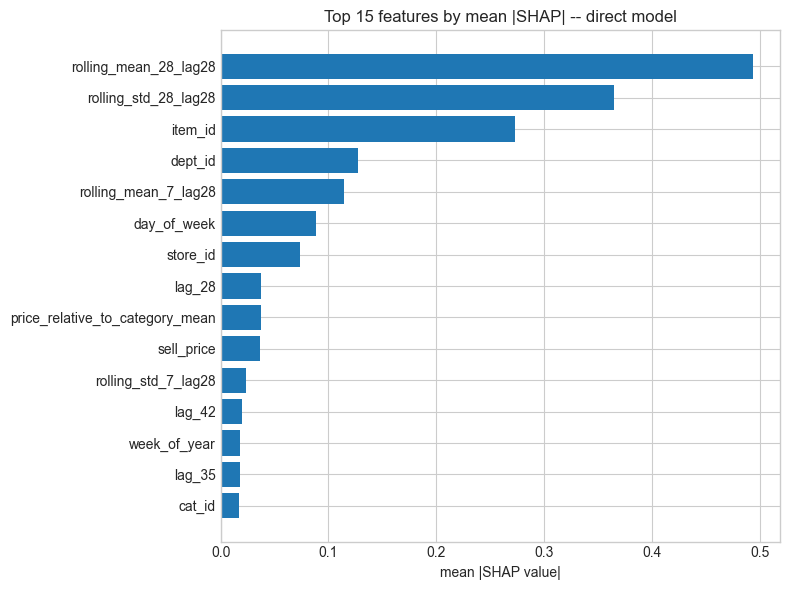

In [9]:
top15 = importance.sort_values("mean_abs_shap", ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["feature"], top15["mean_abs_shap"])
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Top 15 features by mean |SHAP| -- direct model")
fig.tight_layout()
fig.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()

In [10]:
# Does a SNAP-days flag matter more for FOODS (SNAP funds groceries) than
# for HOBBIES / HOUSEHOLD?
snap = importance_by_cat[importance_by_cat["feature"].str.startswith("is_snap")]
snap.pivot(index="feature", columns="group", values="mean_abs_shap")[["FOODS", "HOBBIES", "HOUSEHOLD"]]

group,FOODS,HOBBIES,HOUSEHOLD
feature,,,
is_snap_CA,0.0176,0.0117,0.0131
is_snap_TX,0.0211,0.0117,0.0120
is_snap_WI,0.0182,0.0079,0.0082


## Key finding: demand history dominates; SNAP timing is a real but second-order, category-specific effect

- **Demand history and item identity dominate.** `rolling_mean_28_lag28` and
  `rolling_std_28_lag28` are the top two features by a wide margin (mean
  |SHAP| 0.49 and 0.36), with `item_id` third (0.27) -- unsurprising for a
  demand forecast, but it's a useful sanity check: the model leans on "what
  has this SKU sold recently" far more than on any single calendar or price
  signal, and no single feature dominates so heavily that the model looks
  fragile to one input.
- **Calendar and price features are all second-tier.** `day_of_week`,
  `sell_price`, and `price_relative_to_category_mean` all land in the 0.03-0.09
  range -- present and used, but an order of magnitude below the demand-history
  block.
- **Supply chain insight: SNAP timing matters more for FOODS, exactly as domain
  knowledge predicts.** SNAP (food-assistance) benefits fund grocery purchases
  specifically, and the per-category SHAP breakdown confirms the model picked
  this up on its own: `is_snap_TX` is ~75% more important for **FOODS**
  (0.021) than for **HOUSEHOLD** (0.012) or **HOBBIES** (0.012), and the same
  FOODS > HOUSEHOLD > HOBBIES ordering holds for `is_snap_CA` and `is_snap_WI`
  too. None of the three crack the global top 10 -- SNAP timing is a
  second-order driver next to demand history and price -- but the *direction*
  of the category split is exactly right, which is the more interesting result
  than the magnitude: it's evidence the model is learning a real behavioral
  signal rather than fitting noise on an arbitrary flag.